In [1]:
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from keras import metrics

# we can do other imports as we go.

2026-03-31 14:44:34.702028: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-31 14:44:34.702273: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 14:44:34.739265: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 14:44:35.950922: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

#### BCO Coral Bleaching - Feature Engineering & Baseline Modeling
**Input:** `bco_supervised_clean.csv` produced by `BCO_Prep_EDA.ipynb` after:
- Dropping 15 unitless ID/comment columns
- Dropping redundant Kelvin, date-part, and SSTA/TSA min/mean columns
- Dropping NaN rows from target, casting all columns to numeric
- Removing 47 fully duplicate rows
- Year extracted from date as temporal feature

**Rows:** 34,468 labeled observations

In [2]:
# Load supervised_df
df_full = pd.read_csv('bco_supervised_clean.csv')

# Shape
print(f"Shape of df_full: {df_full.shape}")
df_full.head()

Shape of df_full: (34468, 38)


,latitude_degrees,longitude_degrees,distance_to_shore,exposure,turbidity,cyclone_frequency,depth_m,substrate_name,percent_cover,percent_bleaching,...,tsa_frequency,tsa_frequency_standard_deviation,tsa_frequencymax,tsa_frequencymean,tsa_dhw,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean,date,year
0,23.163,-82.5260,8519.23,Exposed,0.0287,49.90,10.00,NaN,NaN,50.2,...,0.00,1.09,5.0,0.0,0.00,0.74,7.25,0.18,2005-09-15,2005
1,-17.575,-149.7833,1431.62,Exposed,0.0262,51.20,14.00,NaN,NaN,50.7,...,0.25,0.93,4.0,0.0,0.26,0.67,4.65,0.19,1991-03-15,1991
2,18.369,-64.5640,182.33,Exposed,0.0429,61.52,7.00,NaN,NaN,50.9,...,7.00,1.31,7.0,0.0,0.00,1.04,11.66,0.26,2006-01-15,2006
3,17.760,-64.5680,313.13,Exposed,0.0424,65.39,9.02,NaN,NaN,50.9,...,3.00,0.94,4.0,0.0,0.00,0.75,5.64,0.20,2006-04-15,2006
4,17.769,-64.5830,792.00,Exposed,0.0424,65.39,12.50,NaN,NaN,50.9,...,3.00,1.33,5.0,0.0,0.00,0.92,6.89,0.25,2006-04-15,2006


In [3]:
print(f"Unique values in df_full columns:\n{df_full.nunique().sort_values().head(10)}")
print(f"\nNAN values in df_full columns:\n{df_full.isna().sum().sort_values(ascending=False).head()}")

Unique values in df_full columns:
exposure                     3
substrate_name               3
windspeed                   18
year                        36
tsa_frequencymean           72
ssta_standard_deviation    120
ssta_frequencymean         147
tsa_frequency              197
tsa_frequencymax           216
tsa_dhwmean                232
dtype: int64

NAN values in df_full columns:
substrate_name    12015
percent_cover     11810
depth_m            1679
ssta                122
ssta_dhw            122
dtype: int64


percent_cover and substrate_name have lot of nan's. 
<br>Percent cover is a method of determining relative abundance of a plant or sessile animal based on the amount of space they occupy within a plot of substrate. In this method, rather than counting the number of individuals, each species is assigned a percent cover based on a visual estimate of how much of the sample plot they occupy. So percent_cover depends on substrate, its not missing at random and cannot be imputed. It could be dropped as a feature as its not meaningful for prediction.
<br> substrate_name also cannot be imputed as we don’t know whether missing substrate_name means “no substrate observed”, “not recorded”, etc. But its useful as a feature so we will fill the nan's with the value 'unknown' 

In [4]:
# Its ok to fill nan with 'unknown' for this feature column as it is a categorical label, 
# so there is no risk of data leakage.
df_full['substrate_name'] = df_full['substrate_name'].fillna('unknown')

#### Workflow Planning:

1. Column grouping (already done in BCO_Prep_EDA notebook)
2. Target variable distribution analysis - distribution of percent_bleaching, class imbalance check (already done in BCO_Prep_EDA notebook)
3. Define X, y
4. Data splits - Stratified/ Temporal?
5. Feature distribution within feature groups - histogram/ bar charts.
6. undersampling approach to handle class imbalance  - training set only
7. Feature analysis - Correlation + redundancy analysis - Training set only.
8. Feature selection - drop redundant features, PCA
9. Define baseline model
10. Model fit - train model - training set only
11. Model evaluate - val set only - Accuracy, Precision/ Recall, Confusion matrix 
12. Improved models - RF/Tree/boosting
13. Evaluation - test set only - Accuracy, Precision/ Recall, Macro F1, Confusion matrix 

In [5]:
# Redefine target variable
bins = [-0.01, 11, 30, 100]
labels = [0, 1, 2]  # 0=low, 1=medium, 2=high

df_full['bleaching_bin'] = pd.cut(
    df_full['percent_bleaching'],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

# check the target's class distribution
print(df_full['bleaching_bin'].value_counts().sort_index())
# print(df_full.groupby('bleaching_bin').size())
print(df_full['bleaching_bin'].value_counts(normalize=True).round(3).sort_index())


bleaching_bin
0    27666
1     2525
2     4277
Name: count, dtype: int64
bleaching_bin
0    0.803
1    0.073
2    0.124
Name: proportion, dtype: float64


#### Define X,y variable followed by data splits

In [6]:
# Drop columns not used in modelling
df_full = df_full.drop(columns=['percent_bleaching', 'date', 'percent_cover'], errors='ignore')

## Identify feature columns
feature_cols = [col for col in df_full.columns if col != 'bleaching_bin']

# Define X and y variables
X = df_full[feature_cols]
y = df_full['bleaching_bin']

In [7]:
# Data Split 60:20:20

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

 # Shape of each dataframe
print('Size of X_train', X_train.shape)
print('Size of Y_train', y_train.shape)
print('Size of X_val', X_val.shape)
print('Size of Y_val', y_val.shape)
print('Size of X_test', X_test.shape)
print('Size of Y_test', y_test.shape)

Size of X_train (20680, 35)
Size of Y_train (20680,)
Size of X_val (6894, 35)
Size of Y_val (6894,)
Size of X_test (6894, 35)
Size of Y_test (6894,)


In [8]:
# df for y_train and X_train
df_train = pd.concat([pd.DataFrame(y_train), pd.DataFrame(X_train)], axis=1)

In [11]:
df_train.columns

Index(['bleaching_bin', 'latitude_degrees', 'longitude_degrees',
       'distance_to_shore', 'exposure', 'turbidity', 'cyclone_frequency',
       'depth_m', 'substrate_name', 'climsst', 'temperature_mean',
       'temperature_maximum', 'windspeed', 'ssta', 'ssta_standard_deviation',
       'ssta_maximum', 'ssta_frequency', 'ssta_frequency_standard_deviation',
       'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw',
       'ssta_dhw_standard_deviation', 'ssta_dhwmax', 'ssta_dhwmean', 'tsa',
       'tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency',
       'tsa_frequency_standard_deviation', 'tsa_frequencymax',
       'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation',
       'tsa_dhwmax', 'tsa_dhwmean', 'year'],
      dtype='object')

In [12]:
# group feature columns for analysis
feature_groups = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'], #4
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw', 'tsa_dhw'], #5
'ssta_family': [ 'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency', #9
       'ssta_frequency_standard_deviation', 'ssta_frequencymax',
       'ssta_frequencymean', 'ssta_dhw_standard_deviation', 'ssta_dhwmax', 
       'ssta_dhwmean'],
'tsa_family': ['tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency', #9
       'tsa_frequency_standard_deviation', 'tsa_frequencymax', 'tsa_frequencymean', 
       'tsa_dhw_standard_deviation', 'tsa_dhwmax', 'tsa_dhwmean'],
'environmental': ['temperature_mean', 'temperature_maximum', 'windspeed', 'turbidity', #5
                  'cyclone_frequency'],
# 'categorical': ['exposure', 'substrate_name'], #2
'temporal': ['year'], #1
}

In [13]:
# Numeric columns for correlation matrix
numeric_cols = numeric_cols = df_train[feature_cols].select_dtypes(include=['int64', 'float64']).columns

In [17]:
# Correlations with Target
for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 0:
        print(f"\n=== {group_name.upper()} vs TARGET ===")
        corr_vals = df_train[numeric_group_cols].corrwith(df_train['bleaching_bin'])
        display(corr_vals.sort_values(ascending=False))


=== SPATIAL vs TARGET ===


depth_m              0.156266
latitude_degrees     0.081727
distance_to_shore    0.054362
longitude_degrees   -0.160185
dtype: float64


=== THERMAL_BASELINE vs TARGET ===


tsa_dhw     0.263013
ssta_dhw    0.260238
tsa         0.135143
ssta        0.115622
climsst    -0.054991
dtype: float64


=== SSTA_FAMILY vs TARGET ===


...

tsa_frequency                       0.157130
tsa_standard_deviation              0.056375
tsa_maximum                         0.005565
tsa_dhwmax                          0.003403
tsa_dhwmean                        -0.003584
tsa_dhw_standard_deviation         -0.012148
tsa_frequencymean                  -0.040060
tsa_frequencymax                   -0.095760
tsa_frequency_standard_deviation   -0.118155
dtype: float64


=== ENVIRONMENTAL vs TARGET ===


windspeed              0.046599
cyclone_frequency      0.028093
temperature_maximum   -0.015646
turbidity             -0.048702
temperature_mean      -0.074626
dtype: float64


=== TEMPORAL vs TARGET ===


year   -0.198855
dtype: float64

#### I. Correlation results with target:

1. Spatial - weak correlations overall - spatial gradients are not strong predictors of bleaching, they are safe to keep, but they won’t dominate prediction. depth_m (0.155) - `keep`

2. Thermal Baseline - Bleaching is overwhelmingly driven by thermal stress. DHW metrics (ssta_dhw, tsa_dhw) are good predictors so far. DHW (Degree Heating Weeks) variables show the most meaningful relationship with the target as accumulated heat stress is the primary driver of bleaching.
    - **tsa** (0.136) and **ssta** (0.117)
    - **tsa_dhw** (0.256) and **ssta_dhw** (0.255) `keep`, highly correlated with each other - need only 1 of these, but we can keep both for tree‑based models.  

3. SSTA family - This group is highly redundant, and only two features show mild positive correlation
    
    - **ssta_standard_deviation** (0.138) comparable to base SSTA - `Drop?`
    - **ssta_frequency** (0.173) - `keep`
    - **ssta_maximum** (0.007) - `Drop`
    - Most **dhwmean**, **dhw_standard_deviation**, **dhwmax**  (all near zero or negative) `Drop`        

4. TSA family - 
    - **tsa_frequency** (0.149) - `keep` mildly predictive
    - **tsa_maximum** (0.003) - `Drop`
    - everything else is redundant

5. Environment - no meaningful correlation
        - **windspeed** (0.049), **cyclone_frequency** (0.024) - `Drop`
        - **turbidity** (-0.050), **temperature_mean** (-0.077) - `Drop`

6. Temporal - Bleaching severity decreases slightly over time. sampling bias? recovery?
        - **year** (-0.200) — Moderate negative correlation suggests a temporal trend. 


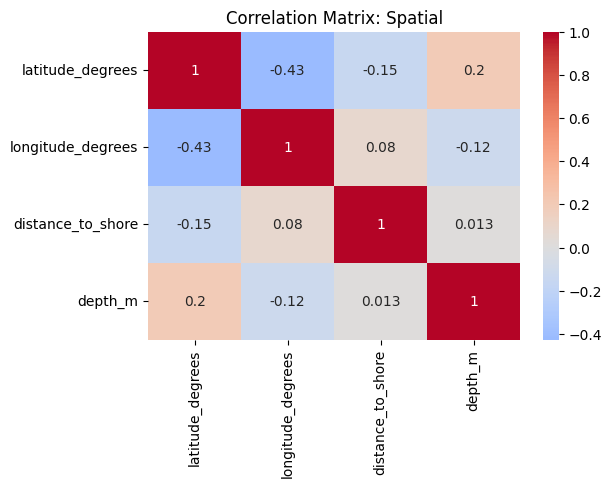

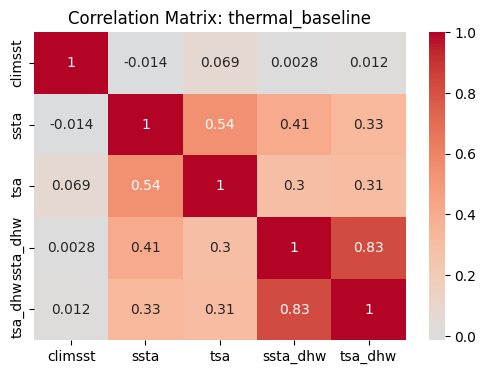

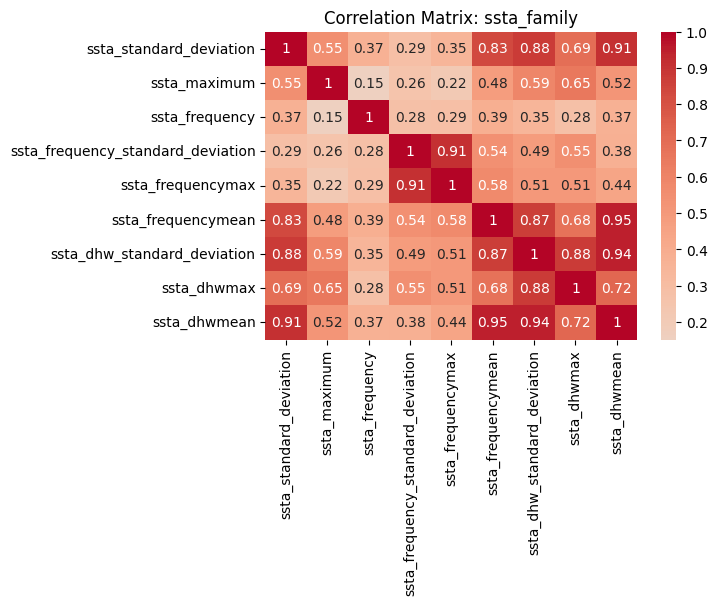

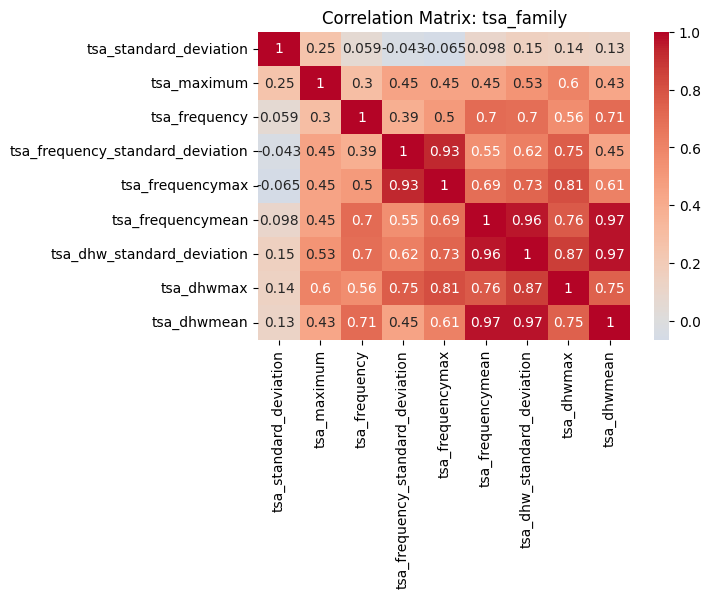

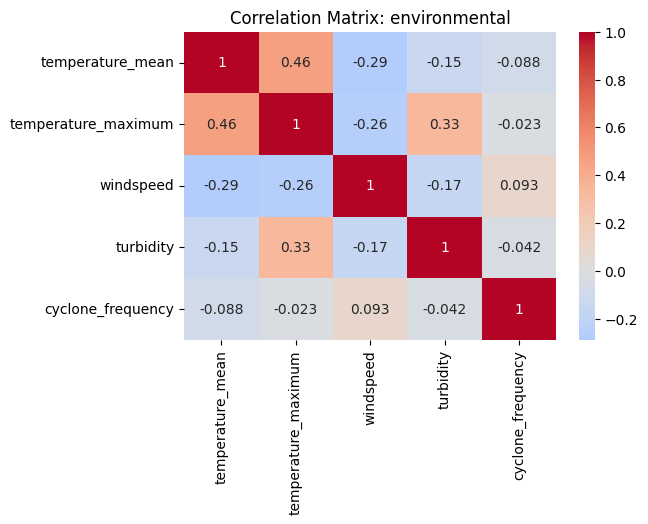

In [19]:
# Correlation between feature groups to check for multicolinearity

for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 1:
        plt.figure(figsize=(6, 4))
        sns.heatmap(df_train[numeric_group_cols].corr(), annot=True, cmap='coolwarm', center=0)
        plt.title(f"Correlation Matrix: {group_name}")
        plt.show()


In [20]:
threshold = 0.4

for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 1:
        corr = df_train[numeric_group_cols].corr()
        filtered = corr[(corr.abs() > threshold) & (corr.abs() != 1)]
        
        print(f"\n=== {group_name.upper()} (|r| > {threshold}) ===")
        display(filtered)



=== SPATIAL (|r| > 0.4) ===


,latitude_degrees,longitude_degrees,distance_to_shore,depth_m
latitude_degrees,NaN,-0.428083,NaN,NaN
longitude_degrees,-0.428083,NaN,NaN,NaN
distance_to_shore,NaN,NaN,NaN,NaN
depth_m,NaN,NaN,NaN,NaN



=== THERMAL_BASELINE (|r| > 0.4) ===


,climsst,ssta,tsa,ssta_dhw,tsa_dhw
climsst,NaN,NaN,NaN,NaN,NaN
ssta,NaN,NaN,0.543184,0.411654,NaN
tsa,NaN,0.543184,NaN,NaN,NaN
ssta_dhw,NaN,0.411654,NaN,NaN,0.825182
tsa_dhw,NaN,NaN,NaN,0.825182,NaN



=== SSTA_FAMILY (|r| > 0.4) ===


,ssta_standard_deviation,ssta_maximum,ssta_frequency,ssta_frequency_standard_deviation,ssta_frequencymax,ssta_frequencymean,ssta_dhw_standard_deviation,ssta_dhwmax,ssta_dhwmean
ssta_standard_deviation,NaN,0.546874,NaN,NaN,NaN,0.829059,0.877975,0.689836,0.908506
ssta_maximum,0.546874,NaN,NaN,NaN,NaN,0.480405,0.589680,0.654364,0.519747
ssta_frequency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ssta_frequency_standard_deviation,NaN,NaN,NaN,NaN,0.911662,0.544776,0.488300,0.551711,NaN
ssta_frequencymax,NaN,NaN,NaN,0.911662,NaN,0.578574,0.505761,0.507738,0.441288
ssta_frequencymean,0.829059,0.480405,NaN,0.544776,0.578574,NaN,0.871602,0.677032,0.946725
ssta_dhw_standard_deviation,0.877975,0.589680,NaN,0.488300,0.505761,0.871602,NaN,0.878147,0.944602
ssta_dhwmax,0.689836,0.654364,NaN,0.551711,0.507738,0.677032,0.878147,NaN,0.719718
ssta_dhwmean,0.908506,0.519747,NaN,NaN,0.441288,0.946725,0.944602,0.719718,NaN



=== TSA_FAMILY (|r| > 0.4) ===


,tsa_standard_deviation,tsa_maximum,tsa_frequency,tsa_frequency_standard_deviation,tsa_frequencymax,tsa_frequencymean,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean
tsa_standard_deviation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tsa_maximum,NaN,NaN,NaN,0.449196,0.448800,0.449011,0.529788,0.601323,0.430937
tsa_frequency,NaN,NaN,NaN,NaN,0.498409,0.703357,0.695520,0.560851,0.705146
tsa_frequency_standard_deviation,NaN,0.449196,NaN,NaN,0.930160,0.553882,0.618059,0.754888,0.453202
tsa_frequencymax,NaN,0.448800,0.498409,0.930160,NaN,0.692917,0.731969,0.814506,0.614374
tsa_frequencymean,NaN,0.449011,0.703357,0.553882,0.692917,NaN,0.961369,0.763123,0.974994
tsa_dhw_standard_deviation,NaN,0.529788,0.695520,0.618059,0.731969,0.961369,NaN,0.866911,0.969544
tsa_dhwmax,NaN,0.601323,0.560851,0.754888,0.814506,0.763123,0.866911,NaN,0.745131
tsa_dhwmean,NaN,0.430937,0.705146,0.453202,0.614374,0.974994,0.969544,0.745131,NaN



=== ENVIRONMENTAL (|r| > 0.4) ===


,temperature_mean,temperature_maximum,windspeed,turbidity,cyclone_frequency
temperature_mean,NaN,0.462018,NaN,NaN,NaN
temperature_maximum,0.462018,NaN,NaN,NaN,NaN
windspeed,NaN,NaN,NaN,NaN,NaN
turbidity,NaN,NaN,NaN,NaN,NaN
cyclone_frequency,NaN,NaN,NaN,NaN,NaN


#### I. Feature correlation results:

1. Spatial - light correlations overall.  - `keep all`

2. Thermal Baseline - Bleaching is overwhelmingly driven by thermal stress. DHW metrics (ssta_dhw, tsa_dhw) are good predictors so far. DHW (Degree Heating Weeks) variables show the most meaningful relationship with the target as accumulated heat stress is the primary driver of bleaching. SSTA and TSA track similar thermal anomalies. DHW metrics are derived from anomalies, so they cluster.
    - **tsa** and **ssta** (0.55) - `keep`
    - **ssta** and **ssta_dhw** (0.41) - `keep`
    - **tsa_dhw** and **ssta_dhw** (0.82) `keep`, highly correlated with each other - need only 1 of these, but we can keep both for tree‑based models.

3. SSTA family - This group has extremely high correlations. classic multicollinearity - features are all derived from the same underlying SST anomaly time series. Run PCA to select features? PCA? dimensionality reduction? or similar to target correlations -
    
    - **ssta_standard_deviation** comparable to base SSTA - `Drop?`
    - **ssta_frequency**  - `keep`
    - **ssta_maximum** - `Drop`
    - Most **dhwmean**, **dhw_standard_deviation**, **dhwmax**  `Drop`        

4. TSA family - mirrors the SSTA family because TSA is a parallel anomaly metric. Group is internally redundant. PCA? dimensionality reduction? or similar to target correlations -
    - **tsa_frequency** - `keep`
    - **tsa_maximum**  - `Drop`
    - everything else is redundant

5. Environment - Only one moderate correlation
        - **temperature_max** and **temperature_mean** (0.45) - `Drop`  

In [21]:
# Feature Selection - selecting 13 features for baseline model as per analysis above.

keep_features = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'],
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw'],
'ssta_family': ['ssta_frequency'],
'tsa_family': ['tsa_frequency'],
'environmental': ['turbidity', 'cyclone_frequency'],
'temporal': ['year'],
'categorical': ['exposure', 'substrate_name']}

# drop_features = {
# 'Spatial': [],
# 'thermal_baseline': ['tsa_dhw'],
# 'ssta_family': [ 'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency_standard_deviation', 
#                 'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw_standard_deviation', 
#                 'ssta_dhwmax', 'ssta_dhwmean'],
# 'tsa_family': ['tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency_standard_deviation', 
#                'tsa_frequencymax', 'tsa_frequencymean', 'tsa_dhw_standard_deviation', 
#                'tsa_dhwmax', 'tsa_dhwmean'],
# 'environmental': ['temperature_mean', 'temperature_maximum', 'windspeed']}

In [22]:
# Flatten the keep_features dictionary into a single list
keep_features_flat = [f for group in keep_features.values() for f in group]

# copy to a new dataframe
df_train = df_train[keep_features_flat]
print(df_train.shape)
df_train.head()

(20680, 15)


,latitude_degrees,longitude_degrees,distance_to_shore,depth_m,climsst,ssta,tsa,ssta_dhw,ssta_frequency,tsa_frequency,turbidity,cyclone_frequency,year,exposure,substrate_name
13193,24.2857,123.7319,942.25,10.0,297.46,0.36,-2.89,0.00,8.00,4.0,0.0317,73.79,2007,Exposed,Nutrient Indicator Algae
44,20.0520,-87.4660,1259.20,7.6,301.38,0.71,-0.66,0.00,3.00,2.0,0.0410,46.93,2005,Exposed,unknown
11905,-5.8204,110.4452,846.39,3.0,302.11,0.22,0.10,4.61,7.00,1.0,0.0634,49.39,2009,Sheltered,Nutrient Indicator Algae
16540,20.3643,-87.3328,370.76,1.5,262.15,0.53,0.43,0.00,0.33,0.0,0.0279,59.85,2003,Exposed,Nutrient Indicator Algae
5243,-0.6900,73.1830,52.87,5.5,302.37,0.73,0.52,0.00,3.00,0.0,0.0387,41.75,2003,Sheltered,unknown


In [23]:
# Compute VIF on the reduced feature set
# VIF runs on numeric data and does not consider Nan's
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF
numeric_cols_for_vif = df_train.select_dtypes(include=['int64', 'float64']).columns
df_vif = df_train[numeric_cols_for_vif].dropna().copy()

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(df_vif.values, i)
    for i in range(df_vif.shape[1])
]

vif_data

,feature,VIF
0,latitude_degrees,2.041888
1,longitude_degrees,1.423321
2,distance_to_shore,1.122782
3,depth_m,4.138469
4,climsst,412.197755
5,ssta,1.719983
6,tsa,1.973776
7,ssta_dhw,2.568312
8,ssta_frequency,4.598123
9,tsa_frequency,2.498860


Most VIF values are between 1 and 5. 3 features stand out: climsst 411, cyclone_frequency 60 and year 464.
climsst is the long‑term climatological SST, and it is strongly tied to lat/long, ssta(anomaly = sst - climsst), tsa, ssta_dhw (derived from anomalies). So it’s mathematically redundant and we can `drop` it. 

cyclone_frequency is surprising and hard to explain. It's probably correlating with a spatial or geographic variable. Cyclone frequency is strongly tied to year and location in many datasets.
If cyclone events cluster in certain years or regions, VIF will explode. - `Drop`

In [24]:
# Drop climsst and rerun VIF
numeric_cols_for_vif = df_train.select_dtypes(include=['int64', 'float64']).columns
numeric_cols_for_vif = numeric_cols_for_vif.drop(['climsst', 'cyclone_frequency'])
df_vif = df_train[numeric_cols_for_vif].dropna().copy()

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data

,feature,VIF
0,latitude_degrees,1.761079
1,longitude_degrees,1.422304
2,distance_to_shore,1.106521
3,depth_m,4.123833
4,ssta,1.709058
5,tsa,1.950145
6,ssta_dhw,2.566371
7,ssta_frequency,4.597699
8,tsa_frequency,2.498752
9,turbidity,2.837413


All spatial + thermal + frequency features look great! everything is below 10. Year has the highest VIF, because thermal anomalies trend over time and bleaching events cluster in certain years - worth keeping an eye on. Keep year for baseline as random forest/ boosting can handle the temporal structure later. 

We are down to 10 numeric + 2categorical features. No need to run PCA for dimensionality reduction as VIF is clean, so there is no colinearity to fix. 

Also skipping feature scaling for baseline, it can be done at the time of running NN.

In [25]:
# Features for baseline model
numeric_features = [
    'latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m', 'ssta', 
    'tsa', 'ssta_dhw', 'ssta_frequency', 'tsa_frequency', 'turbidity', 'year']

categorical_features = ['exposure', 'substrate_name']

#### Model Build + Train

In [26]:
def train_logistic_model(df):

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression

    # Preprocessing
    # -------------------------
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    # Model
    # -------------------------
    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0))
    ])

    # Train
    model.fit(X_train, y_train)

    return model, X_train, X_val, X_test, y_train, y_val, y_test

#### Model Evaluate

In [27]:
def evaluate_model(model, X_val, y_val):

    from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    import numpy as np

    # Predictions
    y_pred = model.predict(X_val)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)

    # Print accuracy, classification report
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    for i, acc in enumerate(per_class_accuracy):
        print(f"Class {i} accuracy: {acc:.3f}")

    overall_accuracy = cm.diagonal().sum() / cm.sum()
    print(f"\nOverall accuracy: {overall_accuracy:.3f}")

    print("\nClassification Report:\n")
    print(classification_report(y_val, y_pred))

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(10, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low Bleaching: 0', 'Medium Bleaching: 1', 'High Bleaching: 2']
    )
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=30)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Metrics
    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    for i in range(len(TP)):
        print(f"\nClass {i}:")
        print(f"  TP = {TP[i]}")
        print(f"  FP = {FP[i]}")
        print(f"  FN = {FN[i]}")
        print(f"  TN = {TN[i]}")

    return cm

#### Function call

Class 0 accuracy: 0.725
Class 1 accuracy: 0.451
Class 2 accuracy: 0.695

Overall accuracy: 0.701

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.72      0.82      5533
           1       0.18      0.45      0.25       505
           2       0.43      0.70      0.53       856

    accuracy                           0.70      6894
   macro avg       0.52      0.62      0.54      6894
weighted avg       0.83      0.70      0.75      6894



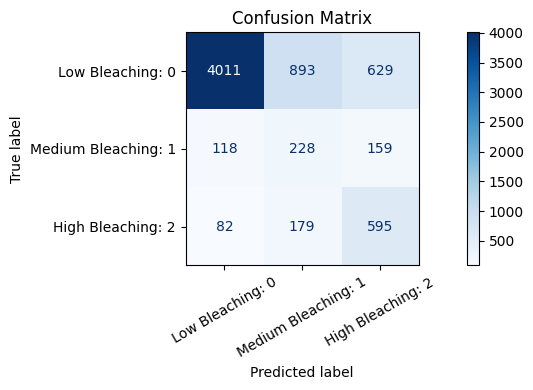


Class 0:
  TP = 4011
  FP = 200
  FN = 1522
  TN = 1161

Class 1:
  TP = 228
  FP = 1072
  FN = 277
  TN = 5317

Class 2:
  TP = 595
  FP = 788
  FN = 261
  TN = 5250


array([[4011,  893,  629],
       [ 118,  228,  159],
       [  82,  179,  595]])

In [28]:
# Evaluate model on df_full

model_full, X_train, X_val, X_test, y_train, y_val, y_test = train_logistic_model(
    df_train)

evaluate_model(model_full, X_val, y_val)

#### Readings:
https://reefcloud.ai/

https://reefcloud.ai/

https://www.geeksforgeeks.org/machine-learning/feature-selection-techniques-in-machine-learning/

https://medium.com/@shiwanigupta3005/feature-selection-techniques-for-classification-models-832ebfc6564d

https://pmc.ncbi.nlm.nih.gov/articles/PMC3347893/
<br>Efficient Feature Selection and Multiclass Classification with Integrated Instance and Model Based Learning: ntegrated KNN and constrained logistic regression (KNNLog) for simultaneous multiclass classification and feature selection. This method simultaneously minimizes the intra-class distance and maximizes the interclass distance with fewer estimated parameters. It is very efficient for problems with small sample size and unbalanced classes.